# Multiple Type Experiment

In [1]:
import warnings;
warnings.filterwarnings('ignore');

from time import sleep
from tqdm.auto import tqdm

import sys
import importlib
import numpy as np
import nbformat
# import plotly.express
# import plotly.express as px
import pandas as pd
import cvxpy as cp
import scipy.optimize as optimization
import matplotlib.pyplot as plt
import seaborn as sns

from algorithms_multiple import *
from radar_plot import *

### Simple Test

In [2]:
prob, solver = generate_cvxpy_solve(2, 2)

solver(np.asarray([1., 1.]), np.asarray([[1,1],[1,1]]), np.asarray([1,1]))

(-7.621974162930201e-10,
 array([[0.5, 0.5],
        [0.5, 0.5]]))

In [3]:
prob, solver = generate_cvxpy_solve(5,3)

### Scaling with n

In [4]:
#np.random.choice(size=5, a=[1.,2.], p=[1/2, 1/2])
1+np.random.poisson(size=5,lam = 1.5)

array([2, 3, 2, 3, 2])

In [5]:
data = []
num_types = 5
num_resources = 3
weights = np.asarray([[1, 2, 3], [1, 3, 2], [4, 1, 5], [1, 2, .5], [3, 7, 5]])
sum_of_rows = weights.sum(axis=1)
weights = weights / sum_of_rows[:, np.newaxis]

algo_list = {'Fixed Threshold': fixed_threshold,
             'Hope Guardrail $L_T = 1/2$': lambda a,b,c,d,e,f: hope_guardrail(a,b,c,d,e,f,1/2),
             'Hope Guardrail $L_T = 1/3$': lambda a,b,c,d,e,f: hope_guardrail(a,b,c,d,e,f,1/3)}
             

num_algo = len(algo_list)

num_iterations = 20
max_n = 100

act_mean = np.asarray([1.5, 2.5, 3.5, 4.5, 5.5])
mean_size = act_mean
stdev_size = mean_size

num_groups = np.logspace(2, 20, base=1.5, num=30).astype(int)

for n in tqdm(num_groups):
    n = int(n) + 5
    print('Num Locations: ' + str(n))
    # pected_size = mean_size
    budget = [np.sum(act_mean)*n, np.sum(act_mean)*n, np.sum(act_mean)*n]
    
    mean = np.array([mean_size,]*n)
    stdev = mean

    alloc_diff = np.zeros((len(algo_list), num_iterations, n, num_types, num_resources)) 
    
    for i in range(num_iterations):
        # size = np.random.choice(size=(n, num_types), a=[1.,2.], p=[1/2, 1/2])
        # size = 1+np.maximum(0, np.random.normal(size=(n, num_types), loc = mean_size-1, scale = .2))
        size = 1 + np.random.poisson(size = (n, num_types), lam = mean_size - 1)
        # print('Size: ' + str(size))
        total_num_types = np.sum(size, axis=0)
        
        prob, solver = generate_cvxpy_solve(num_types, num_resources)

        
        opt = offline_opt(budget, size, weights, solver)
        
        index = 0
        for algo in algo_list:
            
        
            sol, waste = algo_list[algo](budget, size, mean, stdev, weights, solver)
            
            if np.around(np.sum(waste), 3) < 0:
                print(waste)
                print('error!')
            envy = 0
            for k in range(num_types):
                for t in range(n):
                    envy = max(envy, np.abs(np.dot(weights[k, :], opt[t, k, :] - sol[t, k, :])))
            alloc_diff[index, i, :, :, :] = opt - sol
            data_dict = {'NumGroups': n, 'Algorithm': algo, 'Norm': 'Envy', 'Value': envy}
            data.append(data_dict)
            data_dict = {'NumGroups': n, 'Algorithm':algo, 'Norm': 'L1', 'Value': np.sum(np.abs(opt-sol))}
            data.append(data_dict)
            data_dict = {'NumGroups': n, 'Algorithm':algo, 'Norm': 'Linf', 'Value': np.max(np.abs(opt-sol))}
            data.append(data_dict)
            data_dict = {'NumGroups': n, 'Algorithm':algo, 'Norm': 'Waste', 'Value': np.sum(waste)}
            data.append(data_dict)
            index += 1

    index = 0
    for algo in algo_list:
        ex_ante_envy = 0
        for k in range(num_types):
            for t in range(n):
                # print(alloc_diff.shape)
                avg_diff = [np.abs(np.dot(weights[k, :], alloc_diff[index, r, t, k, :])) for r in range(num_iterations)]
                ex_ante_envy = max(ex_ante_envy, np.mean(avg_diff))
        data_dict = {'NumGroups': n, 'Algorithm':algo, 'Norm': 'Ex-Ante Envy', 'Value': ex_ante_envy}
        data.append(data_dict)
        index += 1

  0%|          | 0/30 [00:00<?, ?it/s]

Num Locations: 7
Num Locations: 7
Num Locations: 8
Num Locations: 9
Num Locations: 11
Num Locations: 12
Num Locations: 15
Num Locations: 18
Num Locations: 21
Num Locations: 26
Num Locations: 32
Num Locations: 40
Num Locations: 51
Num Locations: 64
Num Locations: 81
Num Locations: 103
Num Locations: 131
Num Locations: 167
Num Locations: 213
Num Locations: 273
Num Locations: 350
Num Locations: 449
Num Locations: 576
Num Locations: 739
Num Locations: 949
Num Locations: 1220
Num Locations: 1567
Num Locations: 2015
Num Locations: 2590
Num Locations: 3330


<bound method NDFrame.head of       NumGroups                   Algorithm          Norm       Value
0             7             Fixed Threshold          Envy    0.431960
1             7             Fixed Threshold            L1   26.838560
2             7             Fixed Threshold          Linf    0.863920
3             7             Fixed Threshold         Waste   85.059050
4             7  Hope Guardrail $L_T = 1/2$          Envy    0.431960
...         ...                         ...           ...         ...
7285       3330  Hope Guardrail $L_T = 1/3$          Linf    0.244520
7286       3330  Hope Guardrail $L_T = 1/3$         Waste  211.662710
7287       3330             Fixed Threshold  Ex-Ante Envy    0.029638
7288       3330  Hope Guardrail $L_T = 1/2$  Ex-Ante Envy    0.074946
7289       3330  Hope Guardrail $L_T = 1/3$  Ex-Ante Envy    0.155799

[7290 rows x 4 columns]>


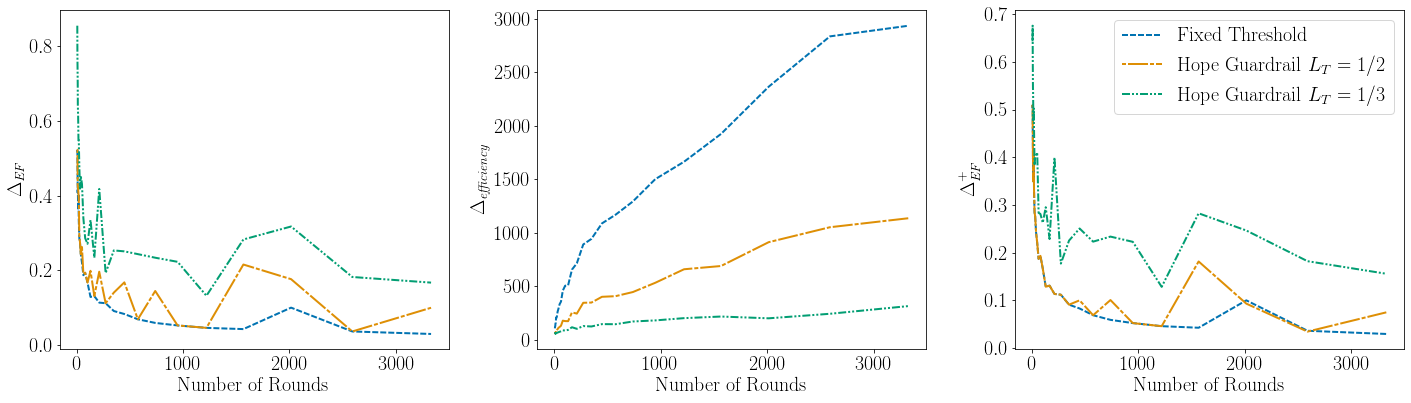

In [6]:
df = pd.DataFrame.from_records(data)

df.columns
df = df.assign(Algorithm = lambda df: df.Algorithm.replace({'fixed_threshold': 'Fixed Threshold', 'hope_guardrail_13': 'Guarded Hope $L_T = T^{-1/3}$', 'hope_guardrail_12': 'Guarded Hope $L_T = T^{-1/2}$'}))

plt.style.use('PaperDoubleFig.mplstyle.txt')
# Make some style choices for plotting 
# colorWheel =['#2bd1e5',
#             '#281bf5',
#              '#db1bf5',
#              '#F5CD1B',
#             '#FF5733','#9cf51b',]
dashesStyles = [[3,1],
            [2,1,10,1],
            [4, 1, 1, 1, 1, 1]] #[1000,1],[8,2]]

print(df.head)


#filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
#plt.figure(figsize=(20,10))
#plt.title('Simple Distribution L1')
#sns.lineplot(x='NumGroups', y='value', hue='variable', data=df[df.Norm == 'L1'])

filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
dash_styles = ["",
               (4, 1.5),
               (1, 1),
               (3, 1, 1.5, 1),
               (5, 1, 1, 1),
               (5, 1, 2, 1, 2, 1),
               (2, 2, 3, 1.5),
               (1, 2.5, 3, 1.2)]

# fig = plt.figure(figsize=(20,6))
plt.rc('text', usetex=True)



fg, axs = plt.subplots(1,3, sharex='all', figsize=(20,6))
sns.lineplot(x='NumGroups', y='Value', hue='Algorithm', style = 'Algorithm', dashes = dashesStyles,
                     data=df[df.Norm == 'Envy'], ax = axs[0], palette = sns.color_palette("colorblind", 3),
            ci = None)
sns.lineplot(x='NumGroups', y='Value', hue='Algorithm', style = 'Algorithm', dashes = dashesStyles, 
             data=df[df.Norm == 'Waste'], ax = axs[1], palette = sns.color_palette("colorblind", 3),
            ci = None)

sns.lineplot(x='NumGroups', y='Value', hue='Algorithm', style = 'Algorithm', dashes = dashesStyles, 
             data=df[df.Norm == 'Ex-Ante Envy'], ax = axs[2], palette = sns.color_palette("colorblind", 3),
            ci = None)



axs[0].get_legend().remove()
axs[0].set_ylabel(r'$\Delta_{\it EF}$')
axs[0].set_xlabel(r'Number of Rounds')

axs[1].set_ylabel(r'$\Delta_{\it efficiency}$')
axs[1].set_xlabel(r'Number of Rounds')
axs[1].get_legend().remove()

axs[2].get_legend().remove()
axs[2].set_ylabel(r'$\Delta_{\it EF}^+$')
axs[2].set_xlabel(r'Number of Rounds')


axs[2].legend(ncol = 1, loc= 'upper right')




plt.show()
# fg.savefig('multi_poisson.pdf', bbox_inches = 'tight',pad_inches = 0.01, dpi=900)


### Group by Group Difference

In [169]:
fair_data = []
expost_data = []


algo_list = {'Fixed Threshold': fixed_threshold,
             'Hope Guardrail $L_T = 1/2$': lambda a,b,c,d,e,f: hope_guardrail(a,b,c,d,e,f,1/2),
             'Hope Guardrail $L_T = 1/3$': lambda a,b,c,d,e,f: hope_guardrail(a,b,c,d,e,f,1/3)}




num_iterations = 200
n = 500


budget = [np.sum(act_mean)*n, np.sum(act_mean)*n, np.sum(act_mean)*n]

mean = np.array([mean_size,]*n)
stdev = mean


alloc_diff = np.zeros((len(algo_list), num_iterations, n, num_types, num_resources)) 


for i in tqdm(range(num_iterations)):

    # print(mean)

    # size = np.random.choice(size=n, a=[1.,2.], p=[1/2, 1/2])
    size = 1 + np.random.poisson(size = (n, num_types), lam = mean_size - 1)# print('Size: ' + str(size))
    total_num_types = np.sum(size, axis=0)

    prob, solver = generate_cvxpy_solve(num_types, num_resources)


    # print(num_types, num_resources, budget.shape size.shape, )

    opt = offline_opt(budget, size, weights, solver)

    # print('opt: ' + str(opt))
    index = 0
    
    
    for algo in algo_list:
        sol, waste = algo_list[algo](budget, size, mean, stdev, weights, solver)
        prop_alloc = budget / np.sum(size)   
        true_envy = 0
        proportional = 0
        
        nsw = 1
        for k in range(num_types):
            for t in range(n):
                nsw +=  size[t,k] * np.log(np.dot(weights[k, :], sol[t, k, :]))
        nsw = max(-10000000, nsw)
        
        
        for k in range(num_types):
            proportional = max(proportional, max(np.dot(weights[k, :], prop_alloc) - np.matmul(sol[:,k,:], weights[k,:])))
        
        for k1 in range(num_types):
            for k2 in range(num_types):
                true_envy = max(envy, max(np.matmul(sol[:,k2,:], weights[k1, :])) - min(np.matmul(sol[:,k1,:], weights[k1,:])))
           
        envy = 0
        for k in range(num_types):
            for t in range(n):
                envy = max(envy, np.abs(np.dot(weights[k, :], opt[t, k, :] - sol[t, k, :])))
                
        alloc_diff[index, i, :, :, :] = opt - sol
        index += 1
        
        fair_data.append({'Iteration':i, 'Algorithm':algo, 
                          '$\Delta_{\it efficiency}$': np.sum(waste) / n, 
                          '\textsc{Envy}'.encode('unicode_escape').decode('utf'): true_envy, 
                          '$\Delta_{\it EF}$': envy, 
                          '$\Delta_{\it Prop}$': proportional, 
                          '\textsc{NSW}'.encode('unicode_escape').decode('utf'): nsw})
            
for i in range(n):
    data.append({'Location': i, 'Algorithm':'Zero', 'Value': 0})
    
    
index = 0
for algo in algo_list:
    ex_ante_envy = (-1)*np.inf
    # print(algo)
    for k in range(num_types):
        for t in range(n):
            # print(alloc_diff.shape)
            avg_diff = [np.abs(np.dot(weights[k, :], alloc_diff[index, r, t, k, :])) for r in range(num_iterations)]
            # print(avg_diff)
            ex_ante_envy = max(ex_ante_envy, np.mean(avg_diff))
    data_dict = {'Algorithm':algo, 'Iteration': 1, '$\Delta_{\it EF}^+$' : ex_ante_envy}
    fair_data.append(data_dict)
    index += 1

  0%|          | 0/200 [00:00<?, ?it/s]

### Printing Fairness Metrics

In hindsight proportional as the same makes sense, as it will be achieved by people obtaining X_lower, which is the same for all the algorithms (and algorithms ensure they don't run out of budget....)

In [170]:
fair_df = pd.DataFrame.from_records(fair_data)

# print(fair_df.columns)
fair_df = fair_df.groupby(['Algorithm']).mean()
print(fair_df)

fair_df['$\Delta_{\it efficiency}$'] = (-1)*fair_df['$\Delta_{\it efficiency}$']
fair_df['\textsc{Envy}'.encode('unicode_escape').decode('utf')] = (-1)*fair_df['\textsc{Envy}'.encode('unicode_escape').decode('utf')]
fair_df['$\Delta_{\it EF}$'] = (-1)* fair_df['$\Delta_{\it EF}$']
fair_df['$\Delta_{\it Prop}$'] = (-1) * fair_df['$\Delta_{\it Prop}$']
fair_df['$\Delta_{\it EF}^+$'] = (-1)*fair_df['$\Delta_{\it EF}^+$']

                            Iteration  $\Delta_{\it efficiency}$  \
Algorithm                                                          
Fixed Threshold              99.00995                   2.257556   
Hope Guardrail $L_T = 1/2$   99.00995                   0.815097   
Hope Guardrail $L_T = 1/3$   99.00995                   0.290061   

                            \textsc{Envy}  $\Delta_{\it EF}$  \
Algorithm                                                      
Fixed Threshold                  0.265887           0.091844   
Hope Guardrail $L_T = 1/2$       0.095881           0.122044   
Hope Guardrail $L_T = 1/3$       0.193278           0.265700   

                            $\Delta_{\it Prop}$   \textsc{NSW}  \
Algorithm                                                        
Fixed Threshold                        0.020192  -48315.211562   
Hope Guardrail $L_T = 1/2$             0.037308 -148088.529621   
Hope Guardrail $L_T = 1/3$             0.071566 -398066.046737   

       

In [171]:
fair_df = normalize(fair_df).drop(['Iteration'], axis=1)
fair_df = fair_df.drop('$\Delta_{\it Prop}$', axis=1)
print(fair_df)

                            $\Delta_{\it efficiency}$  \textsc{Envy}  \
Algorithm                                                              
Fixed Threshold                              0.000000       0.000000   
Hope Guardrail $L_T = 1/2$                   0.733145       1.000000   
Hope Guardrail $L_T = 1/3$                   1.000000       0.427098   

                            $\Delta_{\it EF}$  \textsc{NSW}  \
Algorithm                                                     
Fixed Threshold                      1.000000       1.00000   
Hope Guardrail $L_T = 1/2$           0.826289       0.71473   
Hope Guardrail $L_T = 1/3$           0.000000       0.00000   

                            $\Delta_{\it EF}^+$  
Algorithm                                        
Fixed Threshold                        0.905935  
Hope Guardrail $L_T = 1/2$             1.000000  
Hope Guardrail $L_T = 1/3$             0.000000  


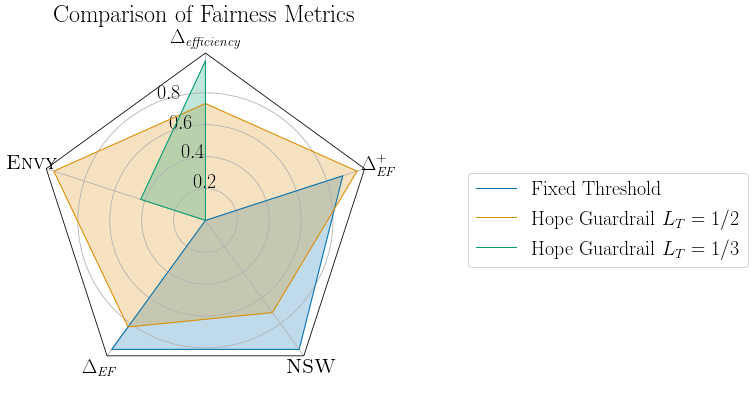

In [172]:
# number of variable



plt.style.use('PaperDoubleFig.mplstyle.txt')


from math import pi


plt.rc('text', usetex=True)




N = len(list(fair_df))
theta = radar_factory(N, frame='polygon')

spoke_labels = list(fair_df)

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(projection='radar'))
fig.subplots_adjust(top=0.85, bottom=0.05)

ax.set_rgrids([0.2, 0.4, 0.6, 0.8])
ax.set_title('Comparison of Fairness Metrics',  position=(0.5, 1.1), ha='center')

index = 0
for algo in algo_list:
    values = fair_df.iloc[index, :].to_numpy()
    ax.plot(theta, values, linewidth=1, linestyle='solid', label=fair_df.index[index], color = sns.color_palette('colorblind', len(algo_list))[index])
    ax.fill(theta, values, color = sns.color_palette('colorblind', len(algo_list))[index],  alpha=0.25)
    index += 1
ax.set_varlabels(spoke_labels)

plt.legend(loc='right', bbox_to_anchor=(2.15, .5))

plt.show()
# plt.savefig('radar.pdf')



